In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
from sentence_transformers import SentenceTransformer

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/US_accidents_dataset.parquet'


#df = pd.read_parquet(file_path)
df = pd.read_parquet(file_path).sample(n=1000000, random_state=42)
print(f"Dataset shape: {df.shape}")

Mounted at /content/drive
Dataset shape: (1000000, 46)


/tmp/ipykernel_1277/1709520609.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Severity', palette='viridis')


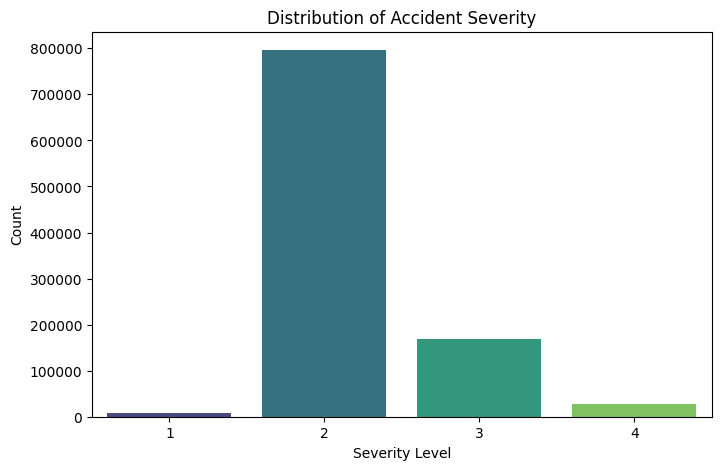

Top 15 missing value percentages:
 End_Lng                  44.0642
End_Lat                  44.0642
Precipitation(in)        28.5607
Wind_Chill(F)            25.8915
Wind_Speed(mph)           7.4402
Visibility(mi)            2.2925
Wind_Direction            2.2818
Humidity(%)               2.2487
Weather_Condition         2.2440
Temperature(F)            2.1189
Pressure(in)              1.8220
Weather_Timestamp         1.5578
Sunrise_Sunset            0.3087
Civil_Twilight            0.3087
Astronomical_Twilight     0.3087
dtype: float64


In [2]:
# Target Variable Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Severity', palette='viridis')
plt.title('Distribution of Accident Severity')
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.show()

# Check missing values (Top 15 features with most NaNs)
missing_percentages = df.isnull().mean() * 100
print("Top 15 missing value percentages:\n", missing_percentages.sort_values(ascending=False).head(15))

In [3]:
# 1. Drop Data Leakage and High-Cardinality/Redundant Columns
columns_to_drop = [
    'ID', 'End_Time', 'Distance(mi)', # Leakage / Target
    'Number', 'Street', 'Zipcode', # NLP/High Cardinality
    'Weather_Timestamp', 'Airport_Code', 'Country', # Redundant
]
df_clean = df.drop(columns=columns_to_drop, errors='ignore')

"""
embedder = SentenceTransformer('all-MiniLM-L6-v2')

descriptions = df_clean['Description'].fillna("").tolist()
embeddings = embedder.encode(descriptions, show_progress_bar=True, batch_size=256)
"""

# Time handling
df_clean['Start_Time'] = pd.to_datetime(df_clean['Start_Time'], format='ISO8601')
df_clean['Hour'] = df_clean['Start_Time'].dt.hour
df_clean['DayOfWeek'] = df_clean['Start_Time'].dt.dayofweek
df_clean['Month'] = df_clean['Start_Time'].dt.month
df_clean = df_clean.drop(columns=['Start_Time'])

# Missing values handling
num_cols = df_clean.select_dtypes(include=['float64', 'int64', 'int32']).columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

# Fill categorical with most repeated value
cat_cols = df_clean.select_dtypes(include=['object', 'bool']).columns
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# 4. Encode Categorical
le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

print(f"Data shape after cleaning: {df_clean.shape}")

Data shape after cleaning: (1000000, 40)


Dimensionality reduction with PCA is implemented due to the large dataset. However, approximately %50 of the features are necessary to explain %90 of the variance, hence this stays as an idea for further work.

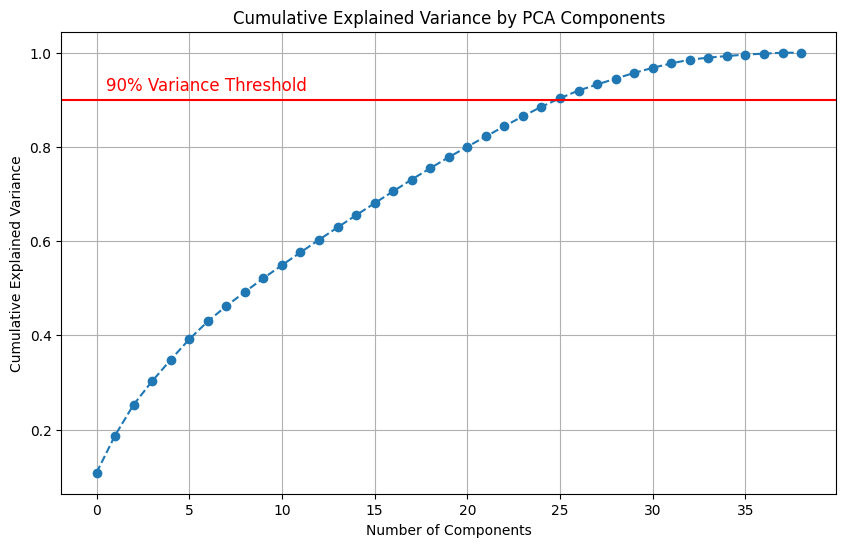

In [4]:
# Separate Features and Target
X = df_clean.drop(columns=['Severity'])
y = df_clean['Severity']

# Scale the data (PCA is highly sensitive to variance scales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA().fit(X_scaled)

# Plot Explained Variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.90, color='r', linestyle='-')
plt.text(0.5, 0.92, '90% Variance Threshold', color = 'red', fontsize=12)
plt.show()


# Classification
I am choosing a Random Forest Classifier. It handles non-linear relationships well, requires less tuning than gradient boosting for baseline setups, and directly outputs feature importance.

In [5]:
# Dset split (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15, # Limited depth to prevent overfitting on such a large dataset
    class_weight='balanced', # Due to imbalance in the labels observed in the EDA section
    random_state=42,
    n_jobs=-1 # Utilize all CPUs
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
print(f"ROC-AUC Score: {roc_auc:.4f}")


--- Classification Report ---
              precision    recall  f1-score   support

           1       0.32      0.87      0.46      1757
           2       0.98      0.75      0.85    159235
           3       0.58      0.92      0.71     33695
           4       0.22      0.79      0.34      5313

    accuracy                           0.78    200000
   macro avg       0.52      0.83      0.59    200000
weighted avg       0.88      0.78      0.81    200000

ROC-AUC Score: 0.9333


/tmp/ipykernel_1277/4103860659.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='mako')


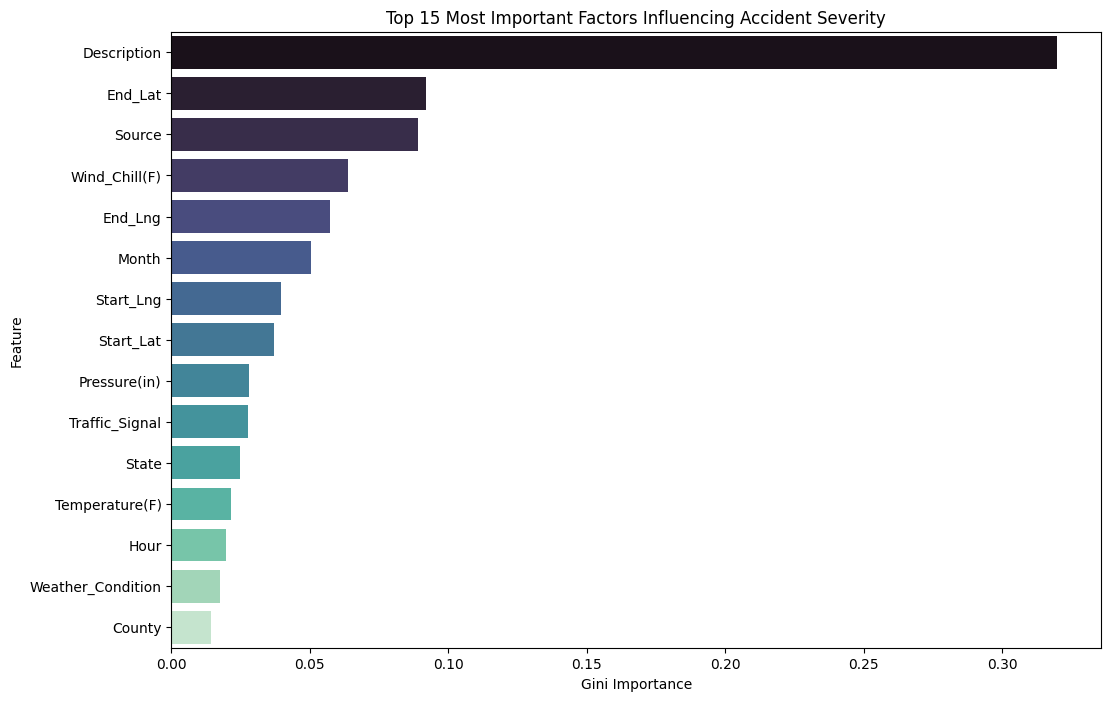

In [6]:
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='mako')
plt.title('Top 15 Most Important Factors Influencing Accident Severity')
plt.xlabel('Gini Importance')
plt.ylabel('Feature')
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=10000),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=20, class_weight='balanced', random_state=42),
    "LightGBM": LGBMClassifier(class_weight='balanced', random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    # ovr = One-vs-Rest for multiclass ROC AUC
    roc = roc_auc_score(y_test, y_proba, multi_class='ovr')

    results[name] = {'Model': model, 'Accuracy': acc, 'ROC_AUC': roc, 'Predictions': y_pred, 'Probas': y_proba}
    print(f"{name} -> Accuracy: {acc:.4f} | ROC AUC: {roc:.4f}")

# Select the best model based on ROC AUC
best_model_name = max(results, key=lambda k: results[k]['ROC_AUC'])
best_model = results[best_model_name]['Model']
print(f"\nBest Model Selected: {best_model_name}")

Training Logistic Regression...
Logistic Regression -> Accuracy: 0.3869 | ROC AUC: 0.7851
Training Random Forest...
Random Forest -> Accuracy: 0.8651 | ROC AUC: 0.9596
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.159031 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2912
[LightGBM] [Info] Number of data points in the train set: 800000, number of used features: 38
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM -> Accuracy: 0.8002 | ROC AUC: 0.9650

Best Model Selected: LightGBM


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


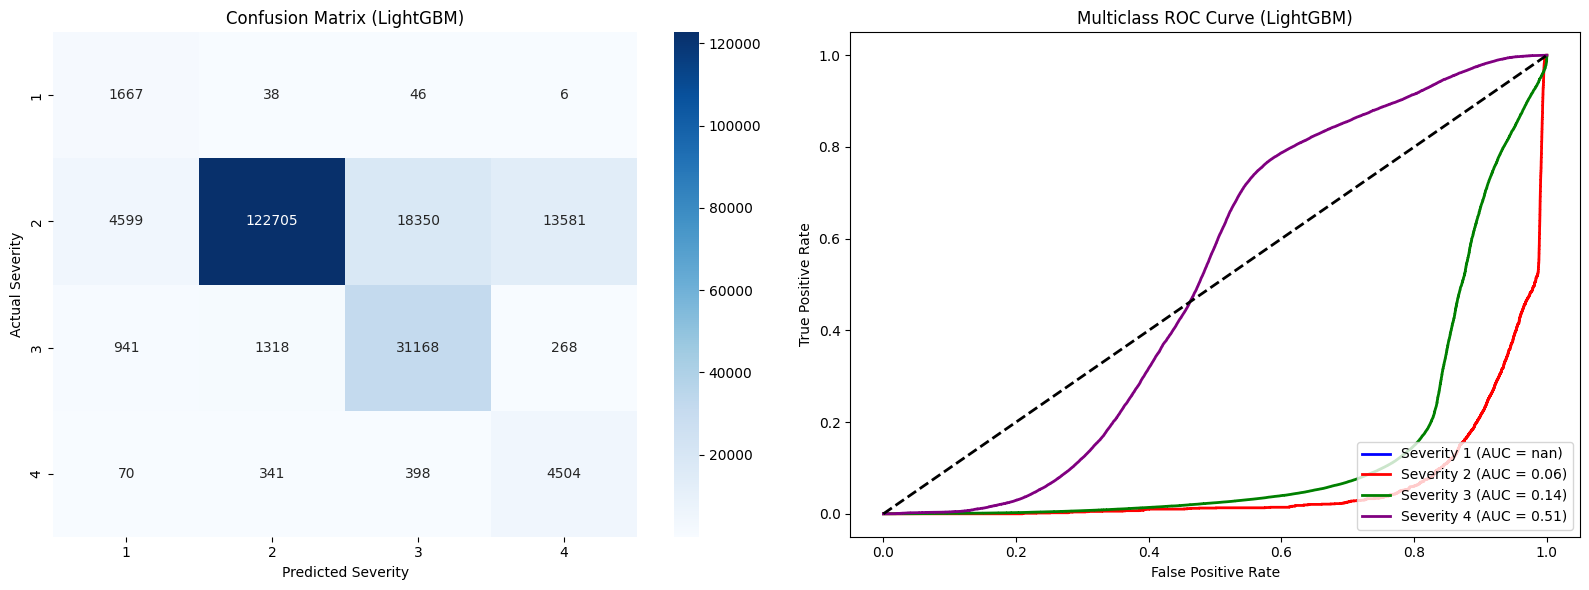


Classification Report:
               precision    recall  f1-score   support

       Sev 1       0.23      0.95      0.37      1757
       Sev 2       0.99      0.77      0.87    159235
       Sev 3       0.62      0.93      0.75     33695
       Sev 4       0.25      0.85      0.38      5313

    accuracy                           0.80    200000
   macro avg       0.52      0.87      0.59    200000
weighted avg       0.90      0.80      0.83    200000



In [8]:
best_preds = results[best_model_name]['Predictions']
best_probas = results[best_model_name]['Probas']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
axes[0].set_title(f'Confusion Matrix ({best_model_name})')
axes[0].set_ylabel('Actual Severity')
axes[0].set_xlabel('Predicted Severity')

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
colors = ['blue', 'red', 'green', 'purple']

for i, color in zip(range(4), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_probas[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'Severity {i+1} (AUC = {roc_auc:.2f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_title(f'Multiclass ROC Curve ({best_model_name})')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print("\nClassification Report:\n", classification_report(y_test, best_preds, target_names=['Sev 1', 'Sev 2', 'Sev 3', 'Sev 4']))

In [ ]:
"""

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Accuracy")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation Accuracy")
plt.title(f'Learning Curve: {best_model_name}')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.legend(loc="best")
plt.grid(True)
plt.show()
"""

In [ ]:
"""
if best_model_name in ["Random Forest", "LightGBM"]:
    importances = best_model.feature_importances_

    # Map back to original feature name
    feature_names = X.columns
    feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(20)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='mako')
    plt.title(f'Top 20 Most Important Features ({best_model_name})')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()
else:
    print("Feature importance requires a tree-based model (LightGBM).")
    """